# Atividades — Disciplina Otimização
**Universidade Federal do Amazonas — PPGEE**  
Prof. Kenny Vinente dos Santos, Dr. | kennyvinente@ufam.edu.br  
Março 2026

---
## Tópico 1
### 1.1 — Problema de Alocação (LP)

Uma pequena empresa de consultoria em engenharia possui **3 projetistas sênior** disponíveis para trabalhar nos **4 projetos** atuais da empresa ao longo das próximas 2 semanas. Cada projetista dispõe de **80 horas** para distribuir entre os projetos.

A tabela abaixo mostra a pontuação do gerente (0 = nenhuma contribuição a 100 = perfeito) sobre a capacidade de cada projetista de contribuir com cada projeto, juntamente com a estimativa de horas que cada projeto exigirá:

| Projetista | Projeto 1 | Projeto 2 | Projeto 3 | Projeto 4 |
|:----------:|:---------:|:---------:|:---------:|:---------:|
| 1          | 90        | 80        | 10        | 50        |
| 2          | 60        | 70        | 50        | 65        |
| 3          | 70        | 40        | 80        | 85        |
| **Requerido** | **70** | **50**    | **85**    | **35**    |

### (a) Formulação do PPL de Alocação

**Conjuntos:**
- $i \in \{1, 2, 3\}$ — projetistas
- $j \in \{1, 2, 3, 4\}$ — projetos

**Variáveis de decisão:**
$$x_{ij} \geq 0 = \text{horas que o projetista } i \text{ aloca ao projeto } j$$

**Função Objetivo** — Maximizar a pontuação total de contribuição:
$$\max Z = \sum_{i=1}^{3} \sum_{j=1}^{4} s_{ij} \cdot x_{ij}$$

Expandida:
$$\max Z = 90x_{11} + 80x_{12} + 10x_{13} + 50x_{14} + 60x_{21} + 70x_{22} + 50x_{23} + 65x_{24} + 70x_{31} + 40x_{32} + 80x_{33} + 85x_{34}$$

**Restrições de disponibilidade** — cada projetista tem no máximo 80 horas:
$$\sum_{j=1}^{4} x_{ij} \leq 80, \quad \forall i \in \{1,2,3\}$$

**Restrições de demanda** — cada projeto recebe exatamente $r_j$ horas:
$$\sum_{i=1}^{3} x_{ij} = r_j, \quad \forall j \in \{1,2,3,4\}$$

**Não-negatividade:**
$$x_{ij} \geq 0, \quad \forall i,j$$

### (b) Solução com JuMP

In [20]:
# Instalar dependências (apenas na primeira vez)
using Pkg
Pkg.add(["JuMP", "HiGHS", "Plots", "StatsPlots"])

   Resolving package versions...
     Project No packages added to or removed from `C:\Users\renye\.julia\environments\v1.12\Project.toml`
    Manifest No packages added to or removed from `C:\Users\renye\.julia\environments\v1.12\Manifest.toml`


In [21]:
using JuMP
using HiGHS
using Plots
using StatsPlots

# ── Dados do problema ──────────────────────────────────────────
S = [90  80  10  50;
     60  70  50  65;
     70  40  80  85]

r = [70, 50, 85, 35]   # horas requeridas por projeto
H = 80                  # horas disponíveis por designer

n_designers = size(S, 1)
n_projects  = size(S, 2)

designer_names = ["Projetista 1", "Projetista 2", "Projetista 3"]
project_names  = ["Projeto 1", "Projeto 2", "Projeto 3", "Projeto 4"];

In [22]:
# ── Modelo LP ──────────────────────────────────────────────────
model = Model(HiGHS.Optimizer)
set_silent(model)

@variable(model, x[1:n_designers, 1:n_projects] >= 0)

@objective(model, Max,
    sum(S[i,j] * x[i,j] for i in 1:n_designers, j in 1:n_projects))

# Restrições de demanda PRIMEIRO (isso ajuda o solver)
@constraint(model, demand[j in 1:n_projects],
    sum(x[i,j] for i in 1:n_designers) == r[j])

# Restrições de disponibilidade DEPOIS
@constraint(model, avail[i in 1:n_designers],
    sum(x[i,j] for j in 1:n_projects) <= H)

optimize!(model)

println("Status : ", termination_status(model))
println("Z*     : ", round(objective_value(model), digits=2))

Status : OPTIMAL
Z*     : 18825.0


In [23]:
# ── Exibir alocação ótima ──────────────────────────────────────
X_opt = value.(x)

println("Alocação ótima (horas):")
println("-" ^ 45)
for i in 1:n_designers
    total = sum(X_opt[i, :])
    println("$(designer_names[i]) — $(round(total, digits=1))h / $(H)h usadas:")
    for j in 1:n_projects
        v = X_opt[i,j]
        if v > 1e-6
            println("  → $(project_names[j]): $(round(v, digits=1))h  (score: $(S[i,j]) × $(round(v,digits=1)) = $(round(S[i,j]*v, digits=1)))")
        end
    end
end

println()
println("Verificação das demandas:")
for j in 1:n_projects
    println("  $(project_names[j]): $(round(sum(X_opt[:,j]), digits=1))h / $(r[j])h requeridas")
end

Alocação ótima (horas):
---------------------------------------------
Projetista 1 — 80.0h / 80h usadas:
  → Projeto 1: 70.0h  (score: 90 × 70.0 = 6300.0)
  → Projeto 2: 10.0h  (score: 80 × 10.0 = 800.0)
Projetista 2 — 80.0h / 80h usadas:
  → Projeto 2: 40.0h  (score: 70 × 40.0 = 2800.0)
  → Projeto 3: 5.0h  (score: 50 × 5.0 = 250.0)
  → Projeto 4: 35.0h  (score: 65 × 35.0 = 2275.0)
Projetista 3 — 80.0h / 80h usadas:
  → Projeto 3: 80.0h  (score: 80 × 80.0 = 6400.0)

Verificação das demandas:
  Projeto 1: 70.0h / 70h requeridas
  Projeto 2: 50.0h / 50h requeridas
  Projeto 3: 85.0h / 85h requeridas
  Projeto 4: 35.0h / 35h requeridas


### Visualização dos Resultados

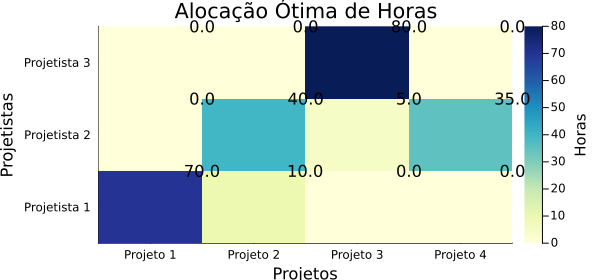

In [24]:
# ── Gráfico 1: Heatmap da alocação ────────────────────────────
hm = heatmap(
    project_names,
    designer_names,
    X_opt,
    color  = :YlGnBu,
    title  = "Alocação Ótima de Horas",
    xlabel = "Projetos",
    ylabel = "Projetistas",
    colorbar_title = "Horas",
    annotations = [(j, i, text(round(X_opt[i,j], digits=1), 11, :black))
                   for i in 1:n_designers for j in 1:n_projects],
    size = (600, 280)
)

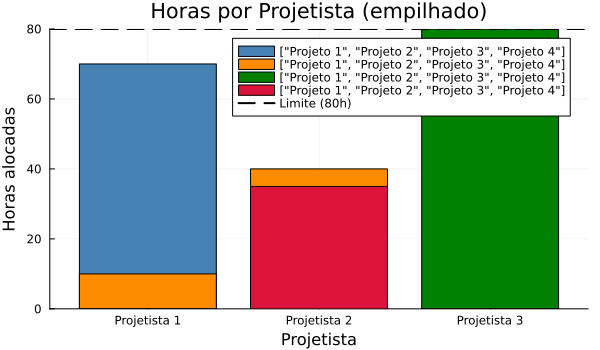

In [25]:
# ── Gráfico 2: Barras empilhadas por projetista ────────────────
proj1 = X_opt[:, 1]
proj2 = X_opt[:, 2]
proj3 = X_opt[:, 3]
proj4 = X_opt[:, 4]

bp = bar(
    designer_names,
    [proj1 proj2 proj3 proj4],
    bar_position = :stack,
    label        = project_names,
    color        = [:steelblue :darkorange :green :crimson],
    title        = "Horas por Projetista (empilhado)",
    xlabel       = "Projetista",
    ylabel       = "Horas alocadas",
    legend       = :topright,
    size         = (600, 350)
)
hline!(bp, [H], linestyle=:dash, color=:black, label="Limite (80h)", linewidth=2)
display(bp)

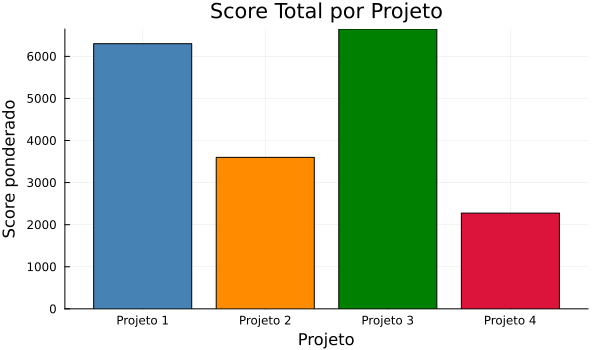

In [26]:
# ── Gráfico 3: Score total por projeto ────────────────────────
contrib = [S[i,j] * X_opt[i,j] for i in 1:n_designers, j in 1:n_projects]
score_por_projeto = vec(sum(contrib, dims=1))

sp = bar(
    project_names,
    score_por_projeto,
    color   = [:steelblue, :darkorange, :green, :crimson],
    title   = "Score Total por Projeto",
    xlabel  = "Projeto",
    ylabel  = "Score ponderado",
    legend  = false,
    size    = (600, 350)
)

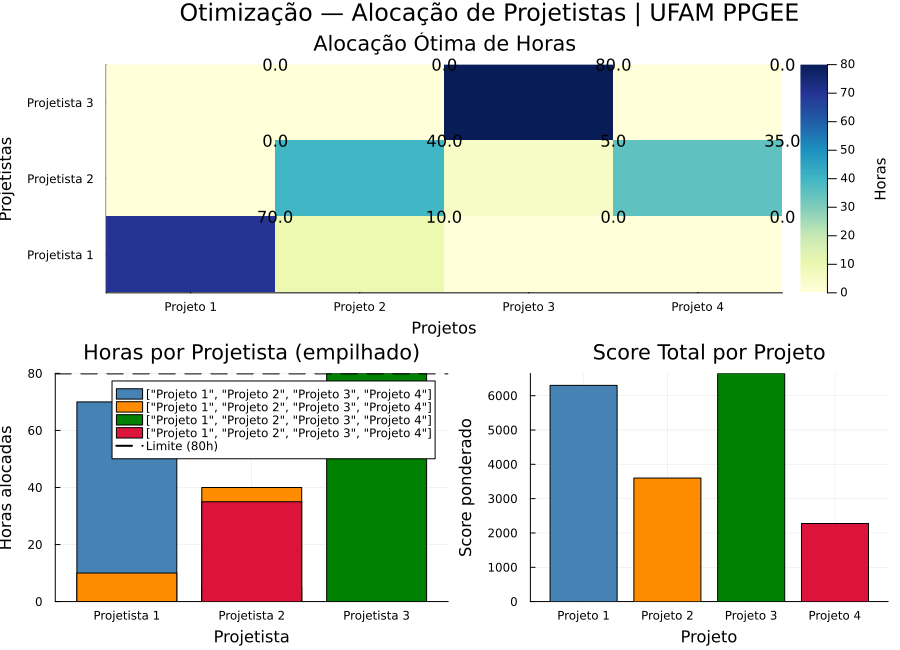

In [27]:
# ── Figura final combinada ─────────────────────────────────────
fig = plot(hm, bp, sp,
    layout     = @layout([a; b c]),
    size       = (900, 650),
    plot_title = "Otimização — Alocação de Projetistas | UFAM PPGEE"
)
savefig(fig, "alocacao_resultado.png")
fig

---
## 1.2 — Provas de Convexidade e Concavidade

### (a) Funções Univariadas

---

**1. $f(x) = e^{ax}$ é convexa em $\mathbb{R}$ para qualquer $a$**

Usando a caracterização de segunda ordem:
$$f''(x) = a^2 e^{ax}$$
Como $a^2 \geq 0$ e $e^{ax} > 0$ para todo $x \in \mathbb{R}$, temos $f''(x) \geq 0$. Portanto $e^{ax}$ é **convexa**. $\square$

---

**2. $f(x) = x^a$ é convexa em $\mathbb{R}_+$ para $a \geq 1$ ou $a \leq 0$**

$$f''(x) = a(a-1)x^{a-2}$$

Para $x > 0$, temos $x^{a-2} > 0$. O sinal depende de $a(a-1)$:
- Se $a \geq 1$: $a > 0$ e $(a-1) \geq 0 \Rightarrow a(a-1) \geq 0$ ✓
- Se $a \leq 0$: $a \leq 0$ e $(a-1) < 0 \Rightarrow a(a-1) \geq 0$ ✓

Logo $f''(x) \geq 0$, confirmando **convexidade**. $\square$

---

**3. $f(x) = x^a$ é côncava em $\mathbb{R}_+$ para $0 \leq a \leq 1$**

Usando o mesmo $f''(x) = a(a-1)x^{a-2}$:
- Se $0 \leq a \leq 1$: $a \geq 0$ e $(a-1) \leq 0 \Rightarrow a(a-1) \leq 0$

Logo $f''(x) \leq 0$, confirmando **concavidade**. $\square$

---

**4. $f(x) = \log x$ é côncava em $\mathbb{R}_{++}$**

$$f''(x) = -\frac{1}{x^2} < 0, \quad \forall x > 0$$

Portanto $\log x$ é **côncava**. $\square$

---

### (b) Função Afim: $f(x) = a^Tx + b$ é convexa e côncava

**Pela definição:** Para todo $x, y \in \mathbb{R}^n$ e $\lambda \in [0,1]$:

$$f(\lambda x + (1-\lambda)y) = a^T(\lambda x + (1-\lambda)y) + b$$
$$= \lambda a^Tx + (1-\lambda)a^Ty + \lambda b + (1-\lambda)b$$
$$= \lambda(a^Tx + b) + (1-\lambda)(a^Ty + b) = \lambda f(x) + (1-\lambda)f(y)$$

A igualdade vale com $=$, portanto $f$ é simultaneamente **convexa** e **côncava**. $\square$

---

### (c) Função Quadrática: $f(x) = \frac{1}{2}x^TQx + b^Tx + c$ é convexa se $Q \succeq 0$

Calculando o gradiente e a Hessiana:
$$\nabla f(x) = Qx + b \qquad \nabla^2 f(x) = Q$$

Uma função é convexa se e somente se sua Hessiana é positiva semidefinida. Como $\nabla^2 f(x) = Q \succeq 0$ por hipótese, $f$ é **convexa**. $\square$

---

### (d) Perda dos Mínimos Quadrados: $f(x) = \|y - Ax\|_2^2$ é sempre convexa

Expandindo:
$$f(x) = (y - Ax)^T(y - Ax) = y^Ty - 2y^TAx + x^TA^TAx$$

Esta é uma função quadrática com $Q = A^TA$. Pela parte (c), basta mostrar que $A^TA \succeq 0$.

**Prova:** Para qualquer $v \in \mathbb{R}^n$:
$$v^T(A^TA)v = (Av)^T(Av) = \|Av\|_2^2 \geq 0$$

Logo $A^TA \succeq 0$ para qualquer matriz $A$, e portanto $\|y - Ax\|_2^2$ é **sempre convexa**. $\blacksquare$

---
*Universidade Federal do Amazonas — PPGEE — Disciplina Otimização — Março 2026*